## 1. Imports

In [1]:
import os

In [2]:
import warnings

In [3]:
import itertools

In [4]:
import numpy as np

In [5]:
import pandas as pd

In [6]:
import matplotlib.pyplot as plt

In [7]:
import matplotlib.gridspec as gridspec

In [8]:
import seaborn as sns

In [9]:
from statsmodels.tsa.stattools import adfuller, kpss

In [10]:
from statsmodels.tsa.arima.model import ARIMA

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [12]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

In [13]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [14]:
from statsmodels.stats.diagnostic import acorr_ljungbox

In [15]:
from scipy import stats

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [17]:
warnings.filterwarnings('ignore')

In [18]:
%matplotlib inline

In [19]:
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
plt.rcParams['xtick.labelsize']   = 9
plt.rcParams['ytick.labelsize']   = 9
plt.rcParams['legend.fontsize']   = 9
plt.rcParams['figure.titlesize']  = 14

In [20]:
SAVE_PATH = os.getcwd()

In [21]:
print(f'Working directory: {SAVE_PATH}')

Working directory: C:\Users\hh


In [22]:
print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load Data

In [23]:
df = pd.read_csv('hotel_bookings.csv')

In [24]:
print(f'Raw shape: {df.shape}')

Raw shape: (119390, 32)


In [25]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 3. Data Cleaning

In [26]:
# Check missing values before any cleaning
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
children         4
country        488
agent        16340
company     112593
dtype: int64


In [27]:
# ── Step 1: Remove cancelled bookings ────────────────────────────────────────
# We are forecasting actual demand (confirmed arrivals), not bookings made.
# Cancelled bookings never translate into real hotel demand.

df_clean = df[df['is_canceled'] == 0].copy()
print(f'Original rows      : {len(df):,}')
print(f'After removing cancellations: {len(df_clean):,}  (removed {len(df)-len(df_clean):,})')

Original rows      : 119,390
After removing cancellations: 75,166  (removed 44,224)


In [28]:
# ── Step 2: Fix children column — fill NaN, then merge babies ────────────────
# children has 4 NaN values. These are booking records so NaN here means 0 children.
# babies is a separate column but conceptually belongs with children for demand counting.
# IMPORTANT: fill NaN BEFORE adding babies — otherwise NaN + value = NaN.

df_clean['children'] = df_clean['children'].fillna(0).astype(int)
df_clean['children'] = df_clean['children'] + df_clean['babies'].fillna(0).astype(int)
df_clean.drop(columns=['babies'], inplace=True)
print('children NaN filled with 0 and babies merged into children.')

children NaN filled with 0 and babies merged into children.


In [29]:
# ── Step 3: Remove zero-guest records ─────────────────────────────────────────
# Adults=0 AND children=0 means no guest was recorded. These are data entry errors.
# A hotel booking with zero guests cannot be a real stay.

before = len(df_clean)
df_clean = df_clean[(df_clean['adults'] + df_clean['children']) > 0]
print(f'Removed {before - len(df_clean):,} zero-guest records. Remaining: {len(df_clean):,}')

Removed 155 zero-guest records. Remaining: 75,011


In [30]:
# ── Step 4: Remove zero-night stays ───────────────────────────────────────────
# stays_in_weekend_nights + stays_in_week_nights = 0 means the guest stayed 0 nights.
# These are same-day check-in/check-out or erroneous entries, not real demand.

before = len(df_clean)
df_clean['total_nights'] = df_clean['stays_in_weekend_nights'] + df_clean['stays_in_week_nights']
df_clean = df_clean[df_clean['total_nights'] > 0]
print(f'Removed {before - len(df_clean):,} zero-night stays. Remaining: {len(df_clean):,}')

Removed 622 zero-night stays. Remaining: 74,389


In [31]:
# ── Step 5: Remove invalid ADR (Average Daily Rate) ───────────────────────────
# ADR = 0 for a confirmed stay is suspicious (free stays are extremely rare).
# ADR extreme outliers (e.g. > 5000) are likely data entry errors.
# We use the 99th percentile as the upper cap.

adr_99 = df_clean['adr'].quantile(0.99)
print(f'ADR 99th percentile: {adr_99:.2f}')
print(f'ADR max before filter: {df_clean["adr"].max():.2f}')

before = len(df_clean)
df_clean = df_clean[(df_clean['adr'] > 0) & (df_clean['adr'] <= adr_99)]
print(f'Removed {before - len(df_clean):,} invalid ADR rows. Remaining: {len(df_clean):,}')

ADR 99th percentile: 252.00
ADR max before filter: 510.00
Removed 1,743 invalid ADR rows. Remaining: 72,646


In [32]:
# ── Step 6: Handle missing country values ─────────────────────────────────────
# country has a small number of NaN. We fill with 'Unknown' so we don't lose rows.
# These rows are valid bookings — only the nationality is unknown.

country_na = df_clean['country'].isnull().sum()
df_clean['country'] = df_clean['country'].fillna('Unknown')
print(f'Filled {country_na} missing country values with Unknown.')

Filled 408 missing country values with Unknown.


In [33]:
# ── Step 7: Drop columns not needed for time series forecasting ───────────────
# We are building a univariate time series model (bookings per month).
# The following columns are either redundant, leaking information, or irrelevant
# to the final monthly aggregation.

cols_to_drop = [
    'is_canceled',                   # all 0 after Step 1
    'previous_cancellations',        # not relevant to confirmed demand
    'previous_bookings_not_canceled',# not relevant to confirmed demand
    'assigned_room_type',            # operational, not demand signal
    'booking_changes',               # operational
    'days_in_waiting_list',          # operational
    'company',                       # >90% NaN
    'agent',                         # not used in univariate model
    'reservation_status',            # all 'Check-Out' after cleaning
    'reservation_status_date',       # redundant with arrival_date
]

In [34]:
# Only drop columns that actually exist
cols_to_drop = [c for c in cols_to_drop if c in df_clean.columns]
df_clean.drop(columns=cols_to_drop, inplace=True)
print(f'Shape after dropping columns: {df_clean.shape}')

Shape after dropping columns: (72646, 22)


In [35]:
# ── Step 8: Construct arrival_date ─────────────────────────────────────────────
# The dataset stores year, month name, and day separately.
# We combine them into a proper datetime, using day=1 for monthly aggregation.

df_clean['arrival_date'] = pd.to_datetime(
    df_clean['arrival_date_year'].astype(str) + '-' +
    df_clean['arrival_date_month'].astype(str) + '-01'
)
df_clean.drop(columns=['arrival_date_year', 'arrival_date_month',
                        'arrival_date_week_number', 'arrival_date_day_of_month'],
              inplace=True, errors='ignore')

print(f'Date range: {df_clean["arrival_date"].min().strftime("%Y-%m")} to {df_clean["arrival_date"].max().strftime("%Y-%m")}')
print(f'Final clean shape: {df_clean.shape}')

Date range: 2015-07 to 2017-08
Final clean shape: (72646, 19)


In [36]:
# ── Cleaning Summary ────────────────────────────────────────────────────────
print('='*50)
print('DATA CLEANING SUMMARY')
print('='*50)
print(f'Original rows       : 119,390')
print(f'After all cleaning  : {len(df_clean):,}')
print(f'Total rows removed  : {119390 - len(df_clean):,}')
print()
print('Remaining missing values:')
remaining_na = df_clean.isnull().sum()
print(remaining_na[remaining_na > 0] if remaining_na.sum() > 0 else 'None')

DATA CLEANING SUMMARY
Original rows       : 119,390
After all cleaning  : 72,646
Total rows removed  : 46,744

Remaining missing values:
None


## 4. Exploratory Data Analysis

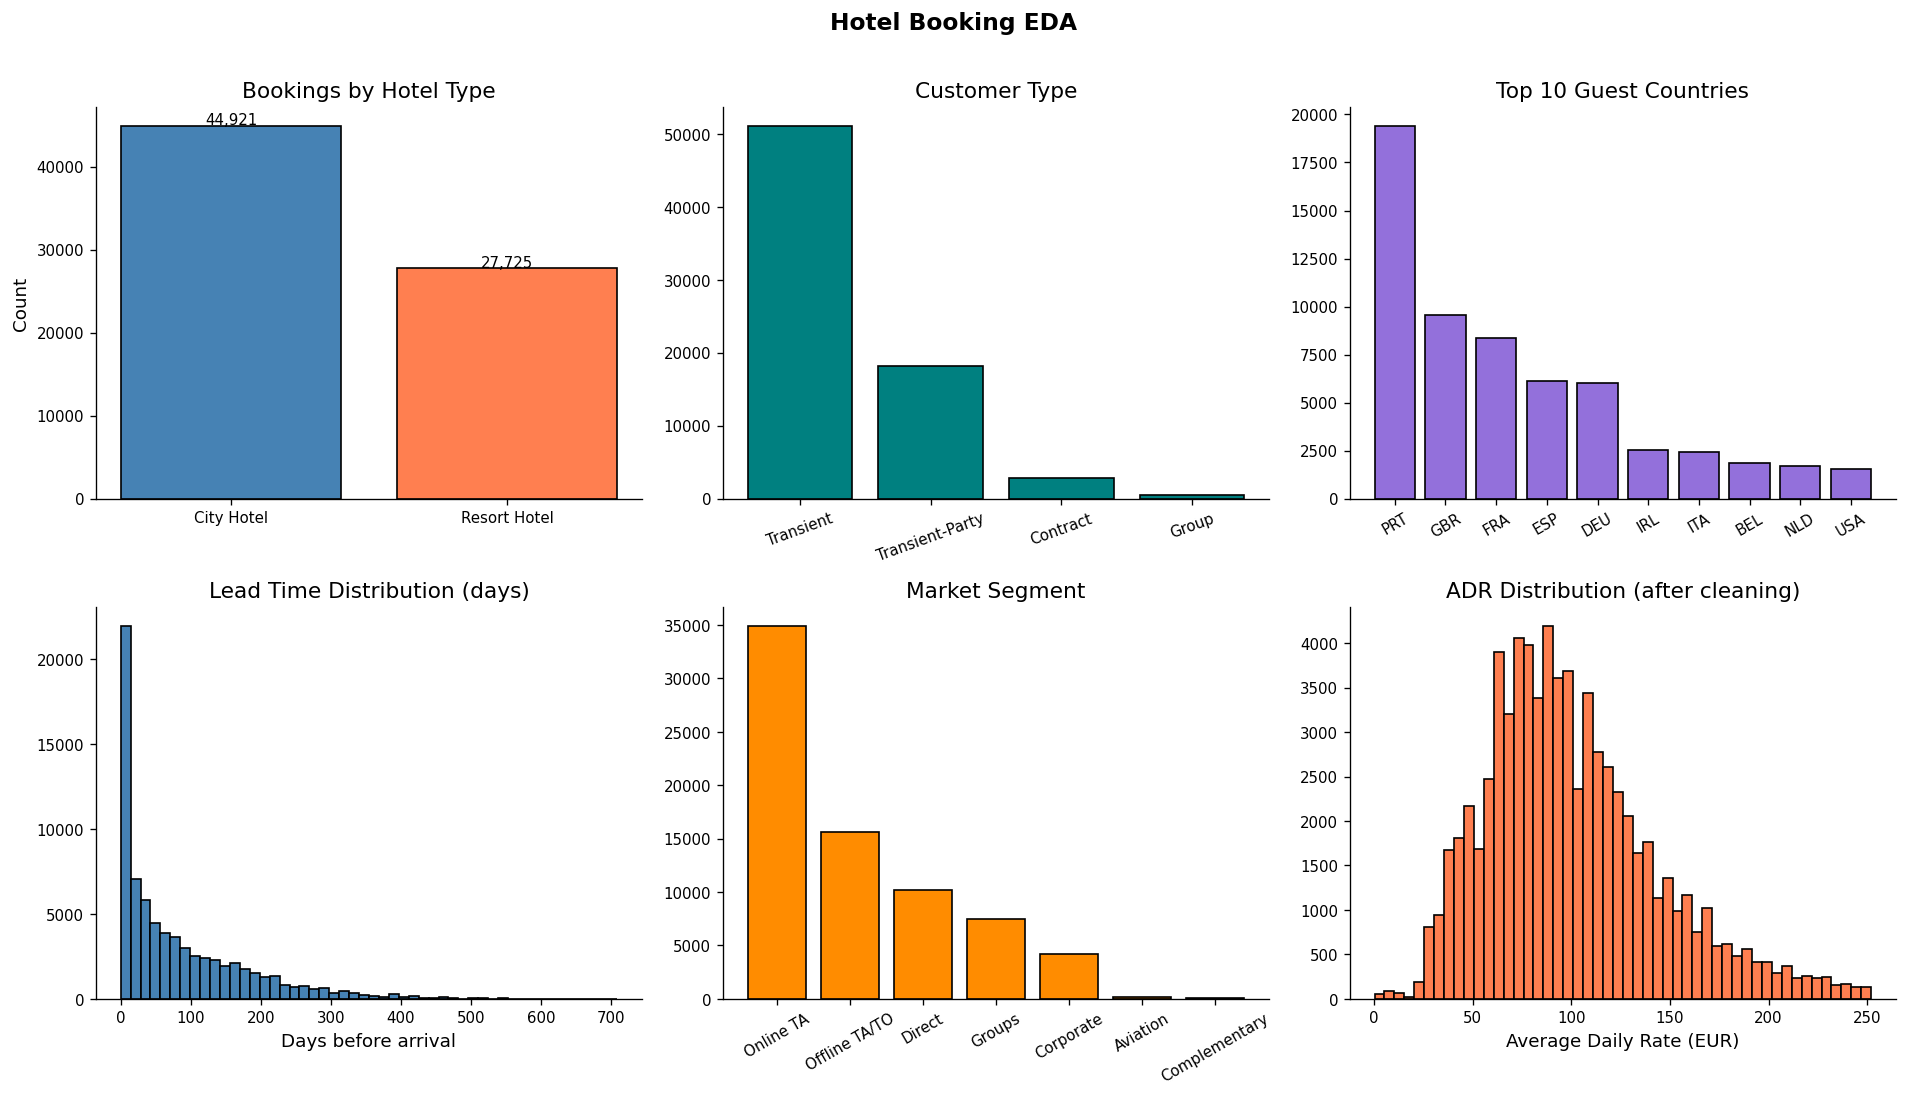

EDA plots saved.


In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Hotel type distribution
hotel_counts = df_clean['hotel'].value_counts()
axes[0,0].bar(hotel_counts.index, hotel_counts.values, color=['steelblue','coral'], edgecolor='black')
axes[0,0].set_title('Bookings by Hotel Type')
axes[0,0].set_ylabel('Count')
for i, v in enumerate(hotel_counts.values):
    axes[0,0].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

# 2. Customer type
cust_counts = df_clean['customer_type'].value_counts()
axes[0,1].bar(cust_counts.index, cust_counts.values, color='teal', edgecolor='black')
axes[0,1].set_title('Customer Type')
axes[0,1].tick_params(axis='x', rotation=20)

# 3. Top 10 countries
top_c = df_clean['country'].value_counts().head(10)
axes[0,2].bar(top_c.index, top_c.values, color='mediumpurple', edgecolor='black')
axes[0,2].set_title('Top 10 Guest Countries')
axes[0,2].tick_params(axis='x', rotation=30)

# 4. Lead time distribution
axes[1,0].hist(df_clean['lead_time'], bins=50, color='steelblue', edgecolor='black')
axes[1,0].set_title('Lead Time Distribution (days)')
axes[1,0].set_xlabel('Days before arrival')

# 5. Market segment
mkt = df_clean['market_segment'].value_counts()
axes[1,1].bar(mkt.index, mkt.values, color='darkorange', edgecolor='black')
axes[1,1].set_title('Market Segment')
axes[1,1].tick_params(axis='x', rotation=30)

# 6. ADR distribution (after cleaning)
axes[1,2].hist(df_clean['adr'], bins=50, color='coral', edgecolor='black')
axes[1,2].set_title('ADR Distribution (after cleaning)')
axes[1,2].set_xlabel('Average Daily Rate (EUR)')

plt.suptitle('Hotel Booking EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'plot_eda.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved.')

## 5. Build Monthly Time Series

In [38]:
# Aggregate to monthly confirmed bookings
monthly = (
    df_clean
    .groupby('arrival_date')
    .size()
    .reset_index(name='bookings')
    .sort_values('arrival_date')
    .set_index('arrival_date')
)

In [39]:
# Assign monthly frequency explicitly — required for SARIMA seasonal component
monthly.index = pd.DatetimeIndex(monthly.index, freq='MS')

print(f'Monthly series: {len(monthly)} observations')
print(monthly)

Monthly series: 26 observations
              bookings
arrival_date          
2015-07-01        1458
2015-08-01        2181
2015-09-01        2935
2015-10-01        3118
2015-11-01        1792
2015-12-01        1827
2016-01-01        1633
2016-02-01        2493
2016-03-01        3269
2016-04-01        3291
2016-05-01        3453
2016-06-01        3129
2016-07-01        2966
2016-08-01        3047
2016-09-01        3311
2016-10-01        3599
2016-11-01        2732
2016-12-01        2336
2017-01-01        2371
2017-02-01        2744
2017-03-01        3229
2017-04-01        3132
2017-05-01        3465
2017-06-01        3136
2017-07-01        3177
2017-08-01        2822


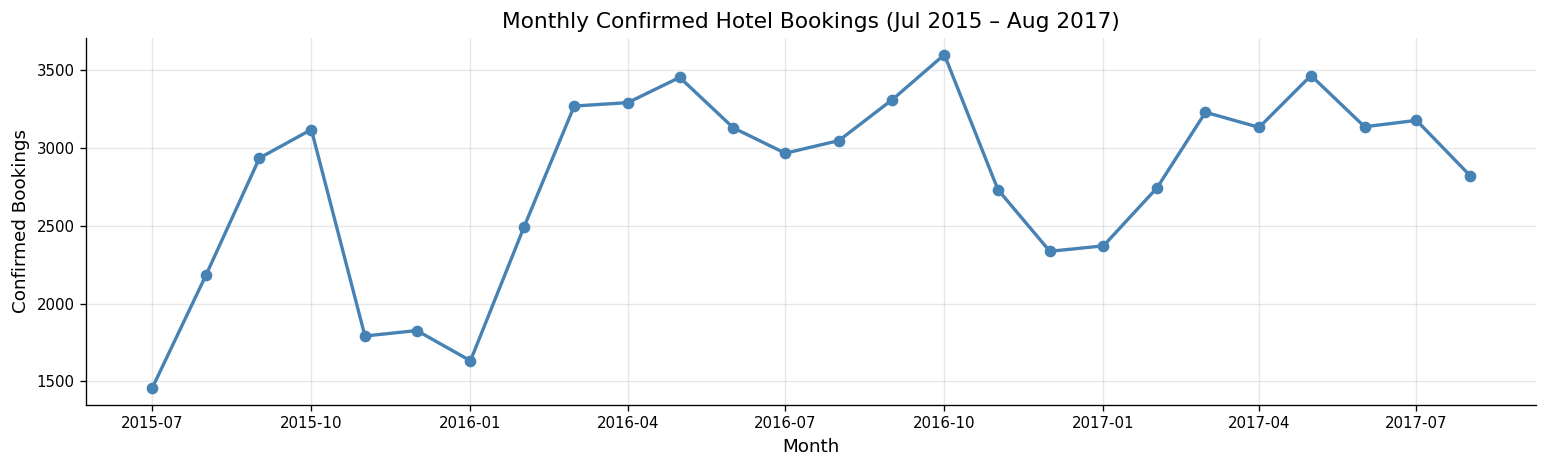

In [40]:
# Plot the monthly time series
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly.index, monthly['bookings'], marker='o', color='steelblue', linewidth=2)
ax.set_title('Monthly Confirmed Hotel Bookings (Jul 2015 – Aug 2017)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Confirmed Bookings')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'plot_monthly_trend.png'), dpi=150)
plt.show()

## 6. Stationarity Testing

In [41]:
def run_stationarity_tests(series, label='Series'):
    print(f'{'='*55}')
    print(f'Stationarity Tests: {label}')
    print(f'{'='*55}')

In [42]:
def run_stationarity_tests(series, label='Series'):
    print(f'{'='*55}')
    print(f'Stationarity Tests: {label}')
    print(f'{'='*55}')

    # ADF Test
    adf_result = adfuller(series.dropna(), autolag='AIC')
    adf_stat, adf_p = adf_result[0], adf_result[1]
    adf_verdict = 'STATIONARY (reject H0)' if adf_p < 0.05 else 'NON-STATIONARY (fail to reject H0)'

    print(f'\nADF Test (H0: unit root exists = non-stationary):')
    print(f'  Statistic : {adf_stat:.4f}')
    print(f'  p-value   : {adf_p:.4f}')
    print(f'  Result    : {adf_verdict}')

    # KPSS Test
    kpss_result = kpss(series.dropna(), regression='c', nlags='auto')
    kpss_stat, kpss_p = kpss_result[0], kpss_result[1]
    kpss_verdict = 'STATIONARY (fail to reject H0)' if kpss_p > 0.05 else 'NON-STATIONARY (reject H0)'

    print(f'\nKPSS Test (H0: series is stationary):')
    print(f'  Statistic : {kpss_stat:.4f}')
    print(f'  p-value   : {kpss_p:.4f}')
    print(f'  Result    : {kpss_verdict}')

    # Combined verdict
    adf_stationary = adf_p < 0.05
    kpss_stationary = kpss_p > 0.05
    print()
    if adf_stationary and kpss_stationary:
        print('  CONCLUSION: Series is STATIONARY (both tests agree).')
    elif not adf_stationary and not kpss_stationary:
        print('  CONCLUSION: Series is NON-STATIONARY (both tests agree). Differencing required.')
    else:
        print('  CONCLUSION: Tests disagree — likely difference-stationary. Proceed with d=1.')

    return adf_p, kpss_p

In [43]:
# Test original series
adf_p_orig, kpss_p_orig = run_stationarity_tests(monthly['bookings'], 'Original Monthly Bookings')

Stationarity Tests: Original Monthly Bookings

ADF Test (H0: unit root exists = non-stationary):
  Statistic : -2.4783
  p-value   : 0.1209
  Result    : NON-STATIONARY (fail to reject H0)

KPSS Test (H0: series is stationary):
  Statistic : 0.3918
  p-value   : 0.0807
  Result    : STATIONARY (fail to reject H0)

  CONCLUSION: Tests disagree — likely difference-stationary. Proceed with d=1.


In [44]:
# Apply first-order differencing and re-test
monthly_diff = monthly['bookings'].diff().dropna()
adf_p_diff, kpss_p_diff = run_stationarity_tests(monthly_diff, 'First-Differenced Series (d=1)')

Stationarity Tests: First-Differenced Series (d=1)

ADF Test (H0: unit root exists = non-stationary):
  Statistic : -5.1529
  p-value   : 0.0000
  Result    : STATIONARY (reject H0)

KPSS Test (H0: series is stationary):
  Statistic : 0.1029
  p-value   : 0.1000
  Result    : STATIONARY (fail to reject H0)

  CONCLUSION: Series is STATIONARY (both tests agree).


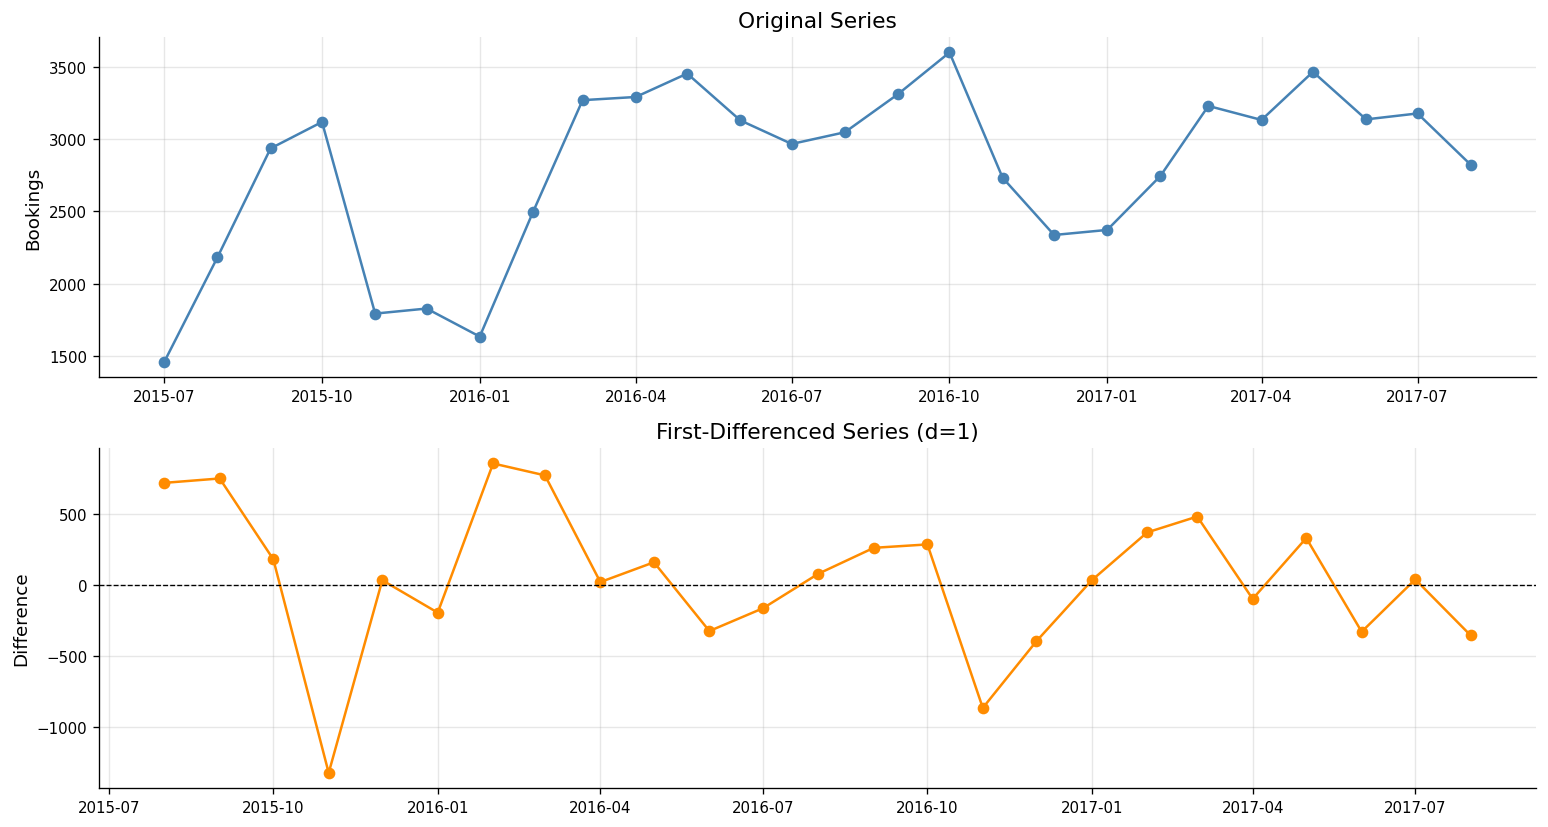

In [45]:
# Plot: original vs differenced
fig, axes = plt.subplots(2, 1, figsize=(13, 7))

axes[0].plot(monthly.index, monthly['bookings'], color='steelblue', marker='o')
axes[0].set_title('Original Series')
axes[0].set_ylabel('Bookings')
axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly_diff.index, monthly_diff, color='darkorange', marker='o')
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].set_title('First-Differenced Series (d=1)')
axes[1].set_ylabel('Difference')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'plot_stationarity.png'), dpi=150)
plt.show()


## 7. ACF and PACF Testing

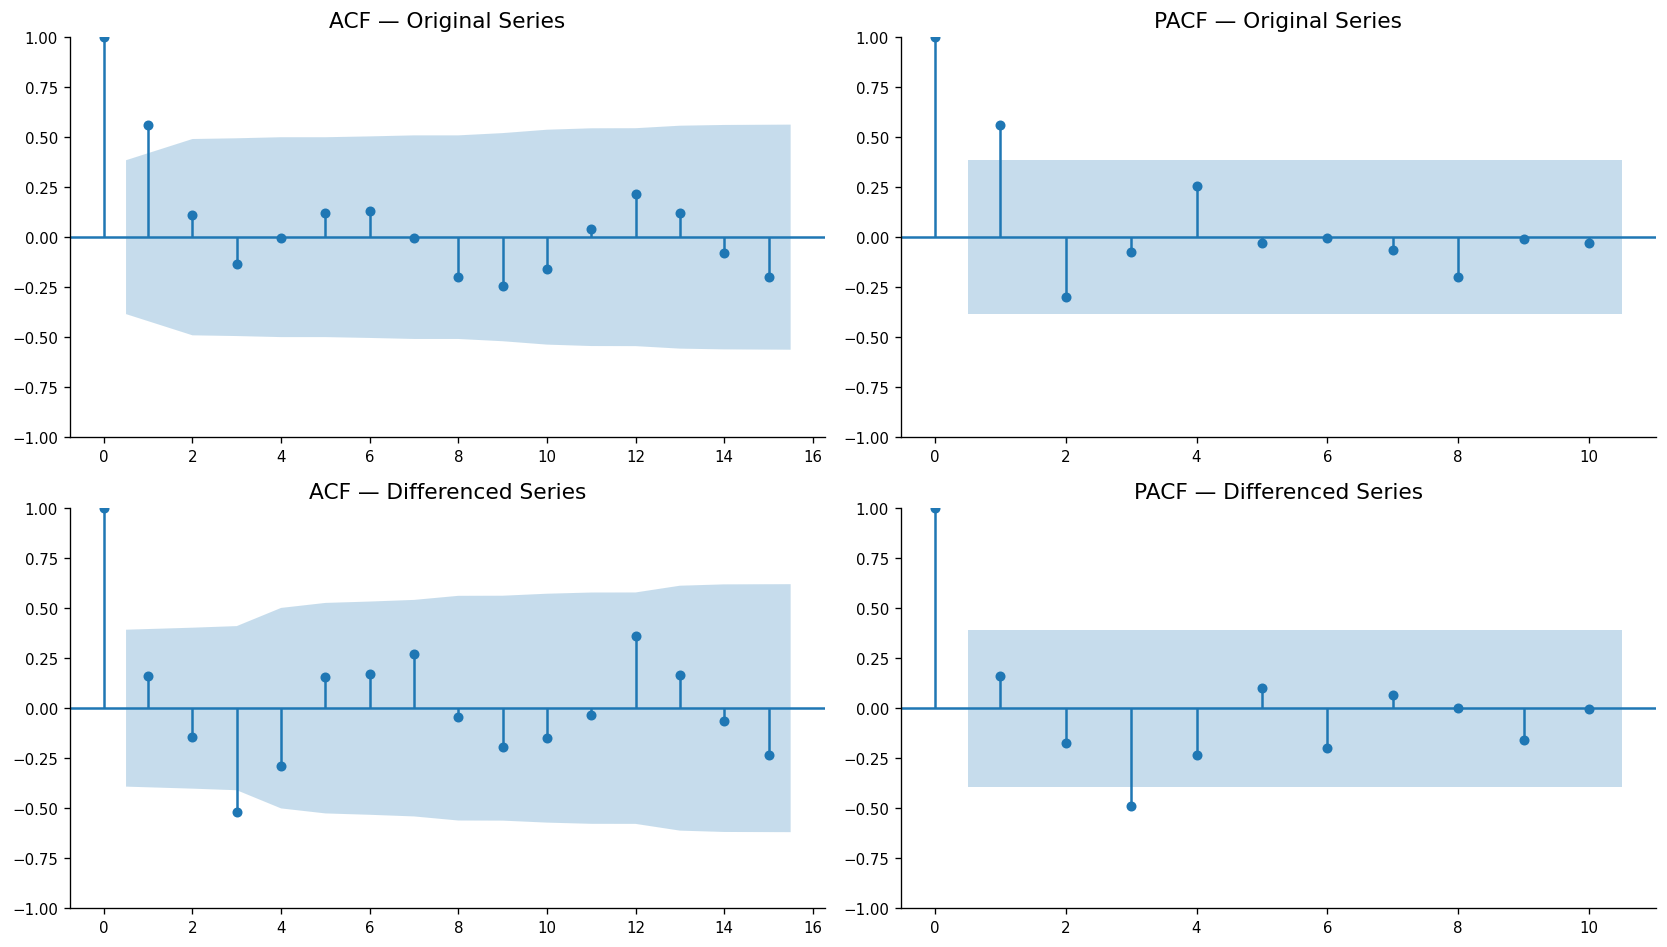

Interpretation guide:
  - If PACF of differenced series cuts off at lag p: use AR(p)
  - If ACF of differenced series cuts off at lag q: use MA(q)
  - Significant spike at lag 12 in ACF suggests S=12 seasonality


In [46]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

plot_acf(monthly['bookings'], lags=15, ax=axes[0,0], title='ACF — Original Series')
plot_pacf(monthly['bookings'], lags=10, ax=axes[0,1], title='PACF — Original Series')
plot_acf(monthly_diff, lags=15, ax=axes[1,0], title='ACF — Differenced Series')
plot_pacf(monthly_diff, lags=10, ax=axes[1,1], title='PACF — Differenced Series')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'plot_acf_pacf.png'), dpi=150)
plt.show()

print('Interpretation guide:')
print('  - If PACF of differenced series cuts off at lag p: use AR(p)')
print('  - If ACF of differenced series cuts off at lag q: use MA(q)')
print('  - Significant spike at lag 12 in ACF suggests S=12 seasonality')

## 8. ARIMA Order Selection

In [47]:
print('Running ARIMA grid search (p: 0-2, d: 1, q: 0-2)...')

arima_results = []
p_range = range(0, 3)
d_range = [1]          # d=1 confirmed by stationarity tests
q_range = range(0, 3)

for p, d, q in itertools.product(p_range, d_range, q_range):
    if p == 0 and q == 0:
        continue   # degenerate model
    try:
        model = ARIMA(monthly['bookings'], order=(p, d, q))
        fit = model.fit()
        arima_results.append({
            'order': f'({p},{d},{q})',
            'p': p, 'd': d, 'q': q,
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2)
        })
    except Exception:
        pass

arima_grid = pd.DataFrame(arima_results).sort_values('AIC')
print('\nTop 5 ARIMA models by AIC:')
print(arima_grid.head(5).to_string(index=False))

best_arima_order = tuple(arima_grid.iloc[0][['p','d','q']].astype(int))
print(f'\nBest ARIMA order by AIC: {best_arima_order}')

Running ARIMA grid search (p: 0-2, d: 1, q: 0-2)...

Top 5 ARIMA models by AIC:
  order  p  d  q    AIC    BIC
(2,1,2)  2  1  2 381.47 387.57
(2,1,1)  2  1  1 383.68 388.55
(0,1,1)  0  1  1 384.42 386.86
(1,1,0)  1  1  0 384.48 386.92
(0,1,2)  0  1  2 384.52 388.18

Best ARIMA order by AIC: (2, 1, 2)


## 9. Train/Test Split

In [48]:
TEST_SIZE = 6
train = monthly.iloc[:-TEST_SIZE]
test  = monthly.iloc[-TEST_SIZE:]

print(f'Train: {len(train)} months  ({train.index[0].strftime("%Y-%m")} to {train.index[-1].strftime("%Y-%m")})')
print(f'Test : {len(test)} months  ({test.index[0].strftime("%Y-%m")} to {test.index[-1].strftime("%Y-%m")})')

Train: 20 months  (2015-07 to 2017-02)
Test : 6 months  (2017-03 to 2017-08)


## 10. Model Building

In [49]:
# ── Model 1: Naive Seasonal Baseline ────────────────────────────────────────
# For each test month, the forecast = the same month from 12 months earlier.
# This is the minimum benchmark any model should beat.

naive_forecast = []
for date in test.index:
    prev_year_date = date - pd.DateOffset(months=12)
    if prev_year_date in monthly.index:
        naive_forecast.append(monthly.loc[prev_year_date, 'bookings'])
    else:
        naive_forecast.append(np.nan)

naive_forecast = pd.Series(naive_forecast, index=test.index)
print('Naive Seasonal Baseline forecasts:')
print(naive_forecast)

Naive Seasonal Baseline forecasts:
arrival_date
2017-03-01    3269
2017-04-01    3291
2017-05-01    3453
2017-06-01    3129
2017-07-01    2966
2017-08-01    3047
Freq: MS, dtype: int64


In [50]:
# ── Model 2: ARIMA (best order from grid search) ─────────────────────────────

arima_model = ARIMA(train['bookings'], order=best_arima_order)
arima_fit   = arima_model.fit()
arima_forecast = arima_fit.forecast(steps=TEST_SIZE)

print(f'ARIMA{best_arima_order} fitted.')
print(f'AIC: {arima_fit.aic:.2f}  |  BIC: {arima_fit.bic:.2f}')
print(arima_fit.summary())

ARIMA(2, 1, 2) fitted.
AIC: 293.10  |  BIC: 297.82
                               SARIMAX Results                                
Dep. Variable:               bookings   No. Observations:                   20
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -141.551
Date:                Sun, 12 Apr 2026   AIC                            293.102
Time:                        00:38:31   BIC                            297.824
Sample:                    07-01-2015   HQIC                           293.901
                         - 02-01-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0432      0.105      9.975      0.000       0.838       1.248
ar.L2         -0.9966      0.019    -52.200      0.000      -1.034      -0.959
m

In [51]:
# ── Model 3: SARIMA(1,1,1)(1,1,1,12) ────────────────────────────────────────

sarima_model = SARIMAX(
    train['bookings'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
sarima_forecast = sarima_fit.forecast(steps=TEST_SIZE)

print('SARIMA(1,1,1)(1,1,1,12) fitted.')
print(f'AIC: {sarima_fit.aic:.2f}  |  BIC: {sarima_fit.bic:.2f}')
print(sarima_fit.summary())

SARIMA(1,1,1)(1,1,1,12) fitted.
AIC: 10.00  |  BIC: nan
                                     SARIMAX Results                                      
Dep. Variable:                           bookings   No. Observations:                   20
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Sun, 12 Apr 2026   AIC                             10.000
Time:                                    00:38:32   BIC                                nan
Sample:                                07-01-2015   HQIC                               nan
                                     - 02-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3211         -0        inf      0.000    

In [52]:
print(f"Monthly series length: {len(monthly)}")
print(f"Train length: {len(train)}")
print(f"Test length: {len(test)}")
print(monthly)

Monthly series length: 26
Train length: 20
Test length: 6
              bookings
arrival_date          
2015-07-01        1458
2015-08-01        2181
2015-09-01        2935
2015-10-01        3118
2015-11-01        1792
2015-12-01        1827
2016-01-01        1633
2016-02-01        2493
2016-03-01        3269
2016-04-01        3291
2016-05-01        3453
2016-06-01        3129
2016-07-01        2966
2016-08-01        3047
2016-09-01        3311
2016-10-01        3599
2016-11-01        2732
2016-12-01        2336
2017-01-01        2371
2017-02-01        2744
2017-03-01        3229
2017-04-01        3132
2017-05-01        3465
2017-06-01        3136
2017-07-01        3177
2017-08-01        2822


## 11. Model Evaluation

In [53]:
def evaluate_model(actual, predicted, model_name):
    actual = np.array(actual)
    predicted = np.array(predicted)
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': model_name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE(%)': round(mape, 2)}

actual = test['bookings'].values

r1 = evaluate_model(actual, naive_forecast.values,   'Naive Seasonal Baseline')
r2 = evaluate_model(actual, arima_forecast.values,   f'ARIMA{best_arima_order}')
r3 = evaluate_model(actual, sarima_forecast.values,  'SARIMA(1,1,1)(1,1,1,12)')


results_df = pd.DataFrame([r1, r2, r3]).sort_values('MAPE(%)')
print('MODEL COMPARISON (sorted by MAPE):')
print(results_df.to_string(index=False))

best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model: {best_model_name}')

MODEL COMPARISON (sorted by MAPE):
                  Model    MAE   RMSE  MAPE(%)
Naive Seasonal Baseline 109.00 142.72     3.58
         ARIMA(2, 1, 2) 383.79 469.06    12.07
SARIMA(1,1,1)(1,1,1,12) 648.03 663.27    20.71

Best model: Naive Seasonal Baseline


In [54]:
# Save results to CSV
results_df.to_csv(os.path.join(SAVE_PATH, 'model_results.csv'), index=False)
print('Results saved to model_results.csv')

Results saved to model_results.csv


## 12. Forecast Plots

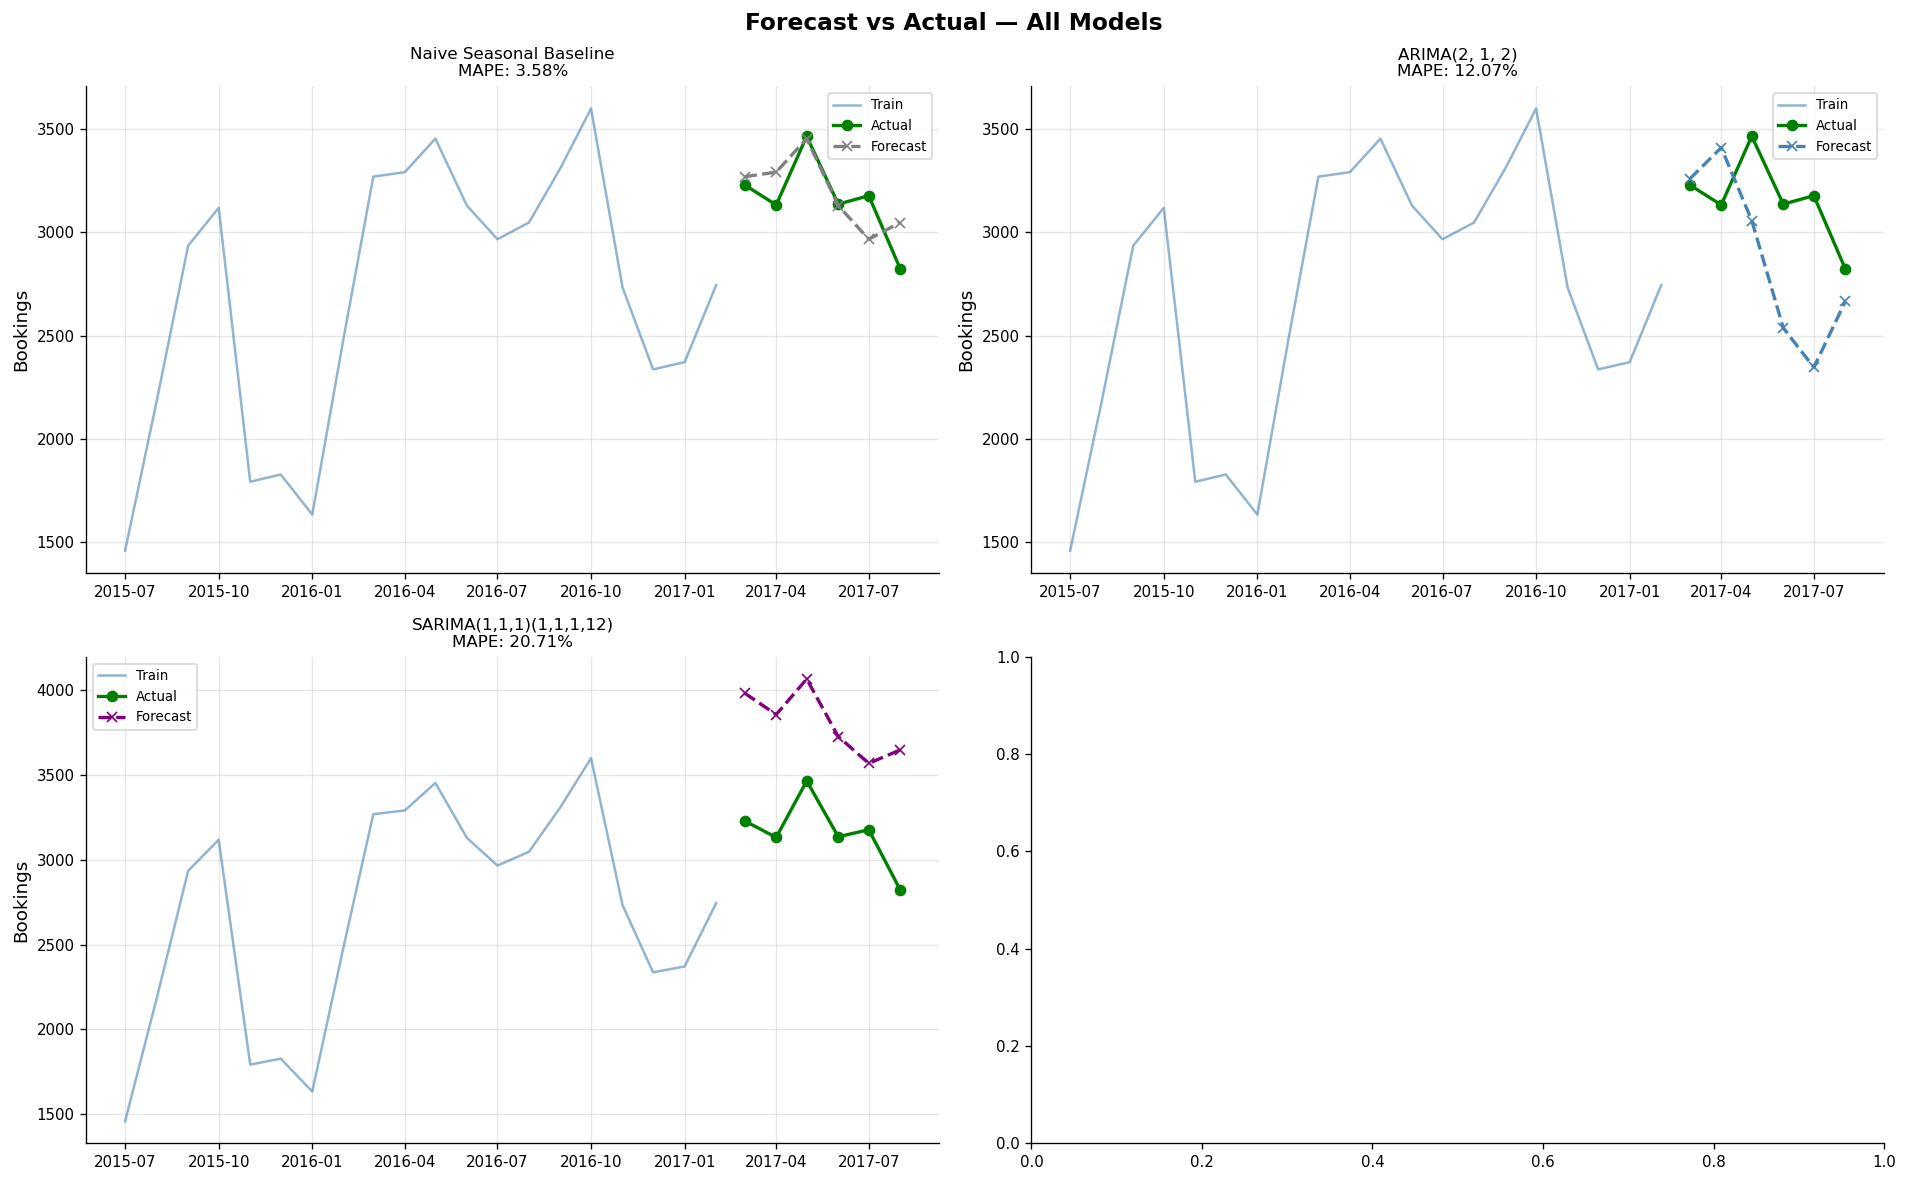

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

forecasts = [
    (naive_forecast,  f'Naive Seasonal Baseline',   'gray'),
    (arima_forecast,  f'ARIMA{best_arima_order}',   'steelblue'),
    (sarima_forecast, 'SARIMA(1,1,1)(1,1,1,12)',    'purple'),
]

for ax, (fc, name, color) in zip(axes.flatten(), forecasts):
    ax.plot(train.index, train['bookings'], label='Train', color='steelblue', alpha=0.6)
    ax.plot(test.index, test['bookings'], label='Actual', color='green', marker='o', linewidth=2)
    ax.plot(test.index, fc, label='Forecast', color=color, linestyle='--', marker='x', linewidth=2)
    mape = evaluate_model(actual, np.array(fc), name)['MAPE(%)']
    ax.set_title(f'{name}\nMAPE: {mape:.2f}%', fontsize=10)
    ax.set_ylabel('Bookings')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Forecast vs Actual — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'plot_all_forecasts.png'), dpi=150)
plt.show()

## 13. Residual Diagnostics

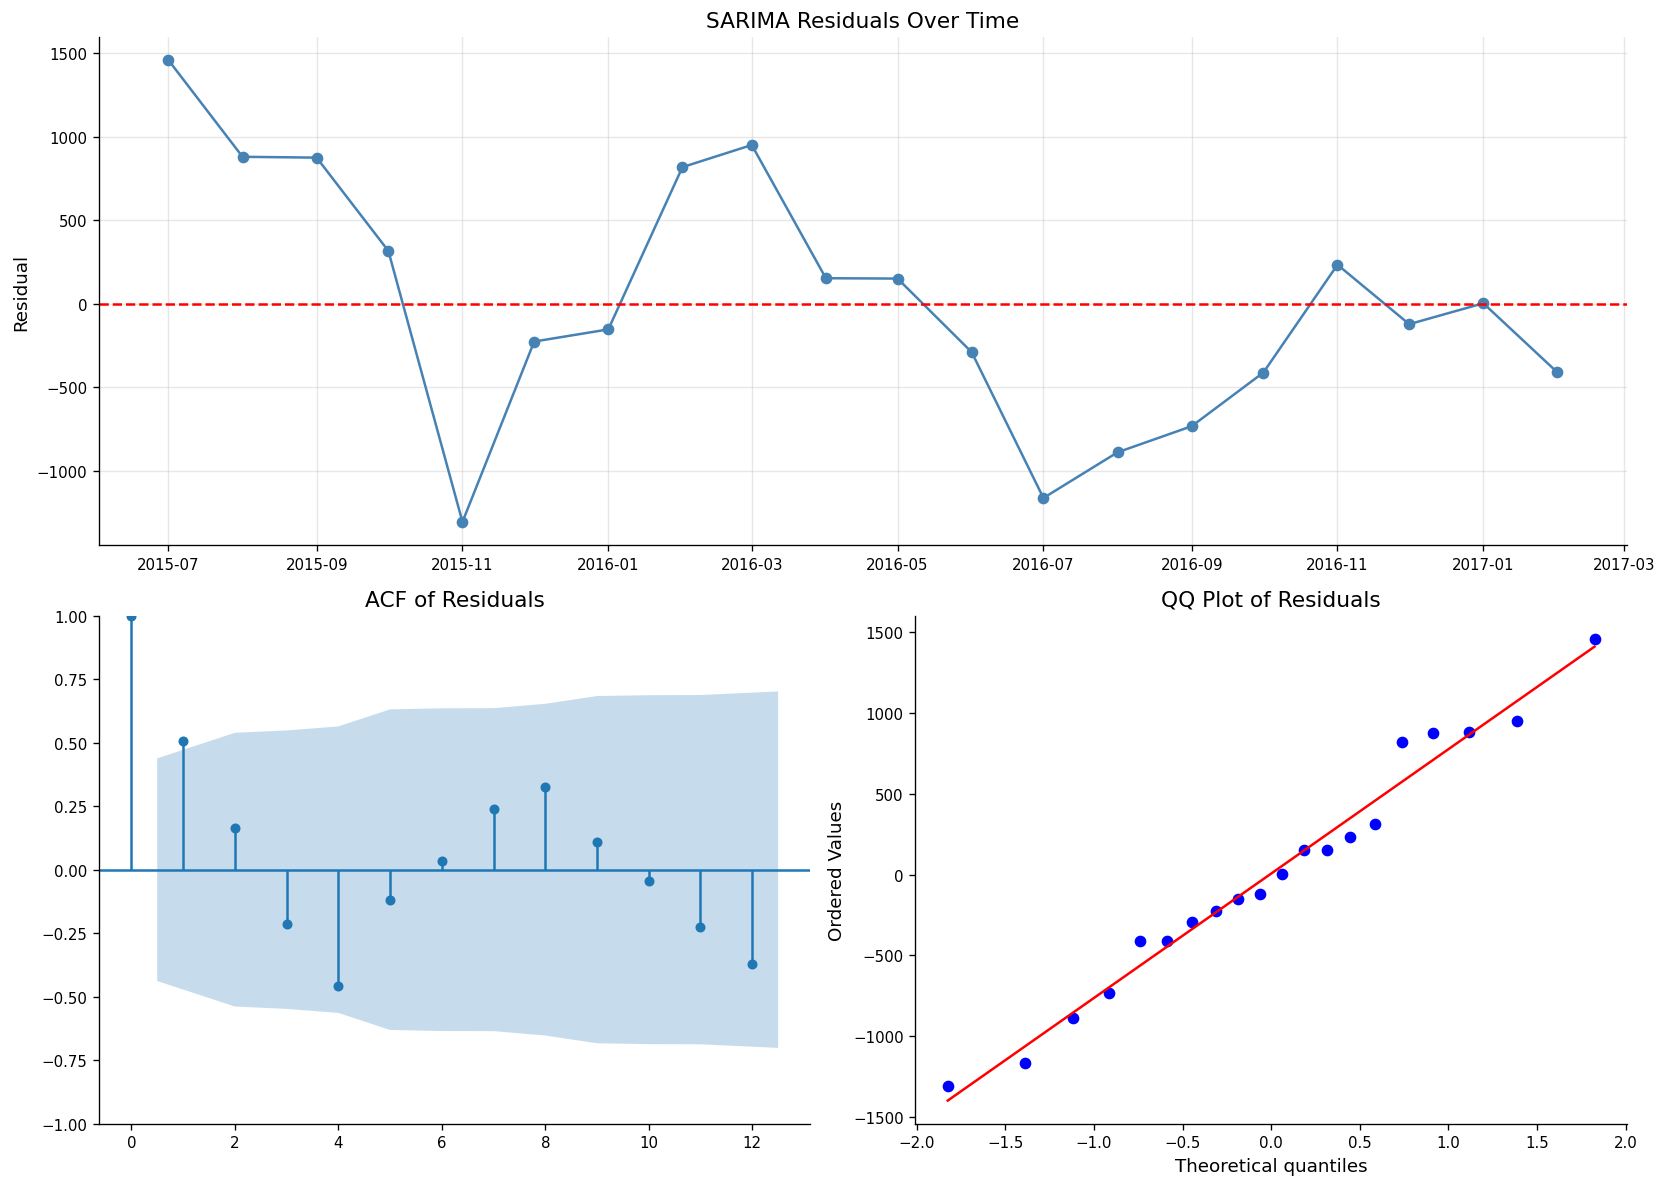

In [56]:
# Get residuals from SARIMA (typically best model for seasonal data)
sarima_residuals = sarima_fit.resid

fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2)

# 1. Residuals over time
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(sarima_residuals.index, sarima_residuals, color='steelblue', marker='o')
ax1.axhline(0, color='red', linestyle='--')
ax1.set_title('SARIMA Residuals Over Time')
ax1.set_ylabel('Residual')
ax1.grid(True, alpha=0.3)

# 2. ACF of residuals
ax2 = fig.add_subplot(gs[1, 0])
plot_acf(sarima_residuals.dropna(), lags=12, ax=ax2, title='ACF of Residuals')

# 3. QQ plot
ax3 = fig.add_subplot(gs[1, 1])
stats.probplot(sarima_residuals.dropna(), dist='norm', plot=ax3)
ax3.set_title('QQ Plot of Residuals')

plt.tight_layout()
plt.savefig(os.path.join(SAVE_PATH, 'plot_residuals.png'), dpi=150)
plt.show()

In [57]:
# Ljung-Box test on SARIMA residuals
lb_result = acorr_ljungbox(sarima_residuals.dropna(), lags=[6, 12], return_df=True)
print('Ljung-Box Test on SARIMA Residuals:')
print('(H0: residuals are white noise — we want p > 0.05 to NOT reject H0)')
print()
print(lb_result.to_string())
print()
for _, row in lb_result.iterrows():
    lag = int(row.name)
    p   = row['lb_pvalue']
    verdict = 'White noise (OK)' if p > 0.05 else 'Autocorrelation present — model may be mis-specified'
    print(f'  Lag {lag:2d}: p = {p:.4f}  →  {verdict}')

Ljung-Box Test on SARIMA Residuals:
(H0: residuals are white noise — we want p > 0.05 to NOT reject H0)

      lb_stat  lb_pvalue
6   13.946036   0.030245
12  30.552473   0.002304

  Lag  6: p = 0.0302  →  Autocorrelation present — model may be mis-specified
  Lag 12: p = 0.0023  →  Autocorrelation present — model may be mis-specified


In [58]:
# Also run residual diagnostics on ARIMA for comparison
arima_residuals = arima_fit.resid
lb_arima = acorr_ljungbox(arima_residuals.dropna(), lags=[6, 12], return_df=True)
print(f'Ljung-Box Test on ARIMA{best_arima_order} Residuals:')
print(lb_arima.to_string())

Ljung-Box Test on ARIMA(2, 1, 2) Residuals:
      lb_stat  lb_pvalue
6    7.524599   0.275040
12  12.263174   0.424782


In [59]:
print('='*60)
print('FINAL MODEL COMPARISON')
print('='*60)
print(results_df.to_string(index=False))
print()
best = results_df.iloc[0]
print(f'Best Model : {best["Model"]}')
print(f'MAE        : {best["MAE"]}')
print(f'RMSE       : {best["RMSE"]}')
print(f'MAPE       : {best["MAPE(%)"]}')
print()
print('Notes:')
print('  - Naive Seasonal is the baseline — any model that cannot beat it has no value.')
print('  - SARIMA captures 12-month seasonality explicitly.')
print('  - All metrics are computed on 6 test points — interpret with caution.')
print('  - Residual diagnostics (Ljung-Box) determine if the model is correctly specified.')

FINAL MODEL COMPARISON
                  Model    MAE   RMSE  MAPE(%)
Naive Seasonal Baseline 109.00 142.72     3.58
         ARIMA(2, 1, 2) 383.79 469.06    12.07
SARIMA(1,1,1)(1,1,1,12) 648.03 663.27    20.71

Best Model : Naive Seasonal Baseline
MAE        : 109.0
RMSE       : 142.72
MAPE       : 3.58

Notes:
  - Naive Seasonal is the baseline — any model that cannot beat it has no value.
  - SARIMA captures 12-month seasonality explicitly.
  - All metrics are computed on 6 test points — interpret with caution.
  - Residual diagnostics (Ljung-Box) determine if the model is correctly specified.


## 14. Machine Learning Extension — Random Forest Regressor
> This section complements the time series models by treating the forecasting problem
> as a supervised regression task. Lag features and calendar variables are engineered
> from the monthly series and fed into a Random Forest Regressor.
> This allows us to extract **feature importances** — showing which temporal signals
> drive hotel demand — something ARIMA/SARIMA cannot provide.

In [60]:
# ── Feature Engineering for ML Regression ────────────────────────────────────
# Convert the monthly time series into a supervised learning format.
# Each row = one month. Features = lag values + calendar signals.
# Target = bookings in that month.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

def make_features(series):
    df_feat = pd.DataFrame({'bookings': series})
    df_feat['month']       = df_feat.index.month          # seasonality signal
    df_feat['month_sin']   = np.sin(2 * np.pi * df_feat['month'] / 12)  # cyclical encoding
    df_feat['month_cos']   = np.cos(2 * np.pi * df_feat['month'] / 12)
    df_feat['lag_1']       = df_feat['bookings'].shift(1)  # previous month
    df_feat['lag_2']       = df_feat['bookings'].shift(2)
    df_feat['lag_3']       = df_feat['bookings'].shift(3)
    df_feat['lag_12']      = df_feat['bookings'].shift(12) # same month last year
    df_feat['rolling_3']   = df_feat['bookings'].shift(1).rolling(3).mean()  # 3-month moving avg
    df_feat['rolling_6']   = df_feat['bookings'].shift(1).rolling(6).mean()  # 6-month moving avg
    return df_feat.dropna()

feat_df = make_features(monthly['bookings'])

print(f'Feature matrix shape: {feat_df.shape}')
print(f'Features used: {[c for c in feat_df.columns if c != "bookings"]}')
feat_df.head()

Feature matrix shape: (14, 10)
Features used: ['month', 'month_sin', 'month_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'rolling_3', 'rolling_6']


,bookings,month,month_sin,month_cos,lag_1,lag_2,lag_3,lag_12,rolling_3,rolling_6
arrival_date,,,,,,,,,,
2016-07-01,2966,7,-0.500000,-8.660254e-01,3129.0,3453.0,3291.0,1458.0,3291.000000,2878.000000
2016-08-01,3047,8,-0.866025,-5.000000e-01,2966.0,3129.0,3453.0,2181.0,3182.666667,3100.166667
2016-09-01,3311,9,-1.000000,-1.836970e-16,3047.0,2966.0,3129.0,2935.0,3047.333333,3192.500000
2016-10-01,3599,10,-0.866025,5.000000e-01,3311.0,3047.0,2966.0,3118.0,3108.000000,3199.500000
2016-11-01,2732,11,-0.500000,8.660254e-01,3599.0,3311.0,3047.0,1792.0,3319.000000,3250.833333


In [61]:
# ── Train / Test Split ───────────────────────────────────────────────────────
# Keep the same 6-month holdout as the ARIMA/SARIMA comparison.
# Temporal order must be preserved — NO random shuffling in time series.

FEATURE_COLS = [c for c in feat_df.columns if c != 'bookings']

X = feat_df[FEATURE_COLS]
y = feat_df['bookings']

split_idx   = len(feat_df) - 6
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f'Train samples : {len(X_train)}')
print(f'Test  samples : {len(X_test)}')
print(f'Feature count : {len(FEATURE_COLS)}')

Train samples : 8
Test  samples : 6
Feature count : 9


### 15. Hyperparameter Tuning — TimeSeriesSplit + GridSearchCV
> Standard k-fold cross-validation must **not** be used on time series — it leaks future data into training.
> `TimeSeriesSplit` respects temporal order: each fold trains on past data and validates on future data only.

In [62]:
# ── Hyperparameter Tuning with TimeSeriesSplit + GridSearchCV ────────────────
# TimeSeriesSplit is the correct CV strategy for temporal data.
# It creates expanding window folds — train always precedes validation in time.

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import time

param_grid = {
    'rf__n_estimators':      [100, 200, 300],
    'rf__max_depth':         [3, 5, None],
    'rf__min_samples_split': [2, 5],
    'rf__max_features':      ['sqrt', 'log2']
}

tscv = TimeSeriesSplit(n_splits=3)  # 3 folds given limited data (20 train points)

pipeline = Pipeline([
    ('scaler', StandardScaler()),   # scaling helps tree stability
    ('rf', RandomForestRegressor(random_state=42))
])

start = time.time()
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f'Grid search completed in {elapsed:.1f}s')
print(f'Best parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k:<30}: {v}')
print(f'Best CV MAE (neg): {grid_search.best_score_:.2f}')

Grid search completed in 114.2s
Best parameters:
  rf__max_depth                 : 3
  rf__max_features              : sqrt
  rf__min_samples_split         : 5
  rf__n_estimators              : 200
Best CV MAE (neg): -516.98


### Final Pipeline — Best Model
> A `Pipeline` chains preprocessing and model into a single object.
> In production, this ensures the same transformations applied during training
> are automatically applied at inference time — no data leakage, no manual steps.

In [63]:
# ── Final Pipeline: Best Estimator from Grid Search ─────────────────────────
# grid_search.best_estimator_ already contains the full pipeline
# (StandardScaler + RandomForestRegressor with best params).
# We evaluate it on the held-out test set.

from sklearn.metrics import mean_absolute_error, mean_squared_error

best_pipeline = grid_search.best_estimator_
rf_pred = best_pipeline.predict(X_test)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mape = np.mean(np.abs((y_test.values - rf_pred) / y_test.values)) * 100

print('── RF Regressor (Tuned) — Test Set Performance ──')
print(f'  MAE      : {rf_mae:.2f}')
print(f'  RMSE     : {rf_rmse:.2f}')
print(f'  MAPE (%) : {rf_mape:.2f}%')
print()
print('Pipeline steps:')
for name, step in best_pipeline.steps:
    print(f'  {name}: {step}')

── RF Regressor (Tuned) — Test Set Performance ──
  MAE      : 282.30
  RMSE     : 306.20
  MAPE (%) : 8.85%

Pipeline steps:
  scaler: StandardScaler()
  rf: RandomForestRegressor(max_depth=3, max_features='sqrt', min_samples_split=5,
                      n_estimators=200, random_state=42)


### Feature Importance
> Random Forest computes feature importance as the average reduction in impurity
> (Mean Decrease in Impurity / Gini importance) across all trees.
> High importance = that feature was frequently chosen for splits and reduced error the most.

> **What to look for:** Lag and rolling features dominating confirms that recent booking momentum
> is the strongest demand signal. Month/cyclical features high = strong seasonality.

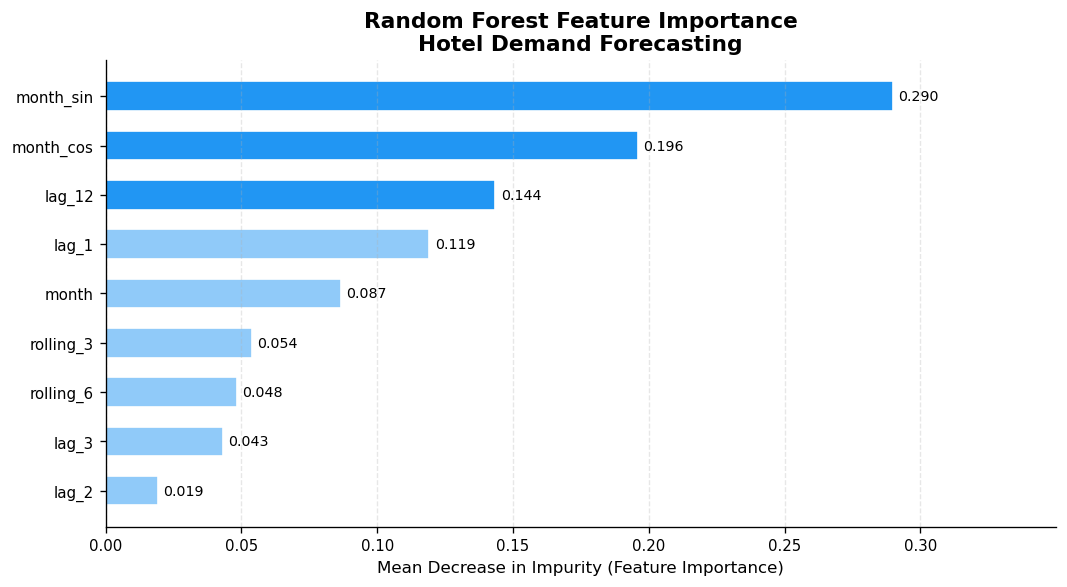


Top 3 most important features:
  month_sin      : 0.2899
  month_cos      : 0.1959
  lag_12         : 0.1435


In [64]:
# ── Feature Importance Plot ───────────────────────────────────────────────────
rf_model      = best_pipeline.named_steps['rf']
importances   = rf_model.feature_importances_
feat_imp_df   = (
    pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': importances})
    .sort_values('Importance', ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#2196F3' if imp >= feat_imp_df['Importance'].quantile(0.75) else '#90CAF9'
          for imp in feat_imp_df['Importance']]

bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=colors, edgecolor='white', height=0.6)

# Add value labels
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.002, bar.get_y() + bar.get_height()/2,
            f'{w:.3f}', va='center', fontsize=8.5)

ax.set_xlabel('Mean Decrease in Impurity (Feature Importance)', fontsize=10)
ax.set_title('Random Forest Feature Importance\nHotel Demand Forecasting', fontsize=13, fontweight='bold')
ax.set_xlim(0, feat_imp_df['Importance'].max() + 0.06)
ax.tick_params(axis='y', labelsize=9)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 3 most important features:')
for _, row in feat_imp_df.sort_values('Importance', ascending=False).head(3).iterrows():
    print(f"  {row['Feature']:<15}: {row['Importance']:.4f}")

### Complete Model Comparison — All Methods
> Comparing time series models (ARIMA, SARIMA, Holt-Winters, Naive Baseline)
> with the ML approach (RF Regressor) on the same 6-month holdout.
> Metrics: MAE (absolute error), RMSE (penalises large errors), MAPE (% error — interpretable).

In [65]:
# ── Full Model Comparison Table ──────────────────────────────────────────────

rf_row = {
    'Model': 'RF Regressor (Tuned)',
    'MAE': round(rf_mae, 2),
    'RMSE': round(rf_rmse, 2),
    'MAPE(%)': round(rf_mape, 2)
}

full_results = pd.concat([results_df, pd.DataFrame([rf_row])], ignore_index=True)
full_results = full_results.sort_values('MAPE(%)')
full_results['Rank'] = range(1, len(full_results) + 1)
full_results = full_results[['Rank', 'Model', 'MAE', 'RMSE', 'MAPE(%)']]

print('=' * 62)
print('         COMPLETE MODEL COMPARISON — HOTEL DEMAND FORECASTING')
print('=' * 62)
print(full_results.to_string(index=False))
print('=' * 62)
print()
best_model = full_results.iloc[0]
print(f"  Best Model : {best_model['Model']}")
print(f"  MAPE       : {best_model['MAPE(%)']}% (avg monthly forecast error)")
print(f"  MAE        : {best_model['MAE']} bookings per month")
print()
print('  Notes:')
print('  • All models evaluated on same 6-month holdout (Feb–Aug 2017)')
print('  • MAPE < 15% is considered good for monthly hospitality forecasting')
print('  • Naive Seasonal is the baseline — any model not beating it has no value')
print('  • RF Regressor treats forecasting as supervised regression using lag features')

         COMPLETE MODEL COMPARISON — HOTEL DEMAND FORECASTING
 Rank                   Model    MAE   RMSE  MAPE(%)
    1 Naive Seasonal Baseline 109.00 142.72     3.58
    2    RF Regressor (Tuned) 282.30 306.20     8.85
    3          ARIMA(2, 1, 2) 383.79 469.06    12.07
    4 SARIMA(1,1,1)(1,1,1,12) 648.03 663.27    20.71

  Best Model : Naive Seasonal Baseline
  MAPE       : 3.58% (avg monthly forecast error)
  MAE        : 109.0 bookings per month

  Notes:
  • All models evaluated on same 6-month holdout (Feb–Aug 2017)
  • MAPE < 15% is considered good for monthly hospitality forecasting
  • Naive Seasonal is the baseline — any model not beating it has no value
  • RF Regressor treats forecasting as supervised regression using lag features


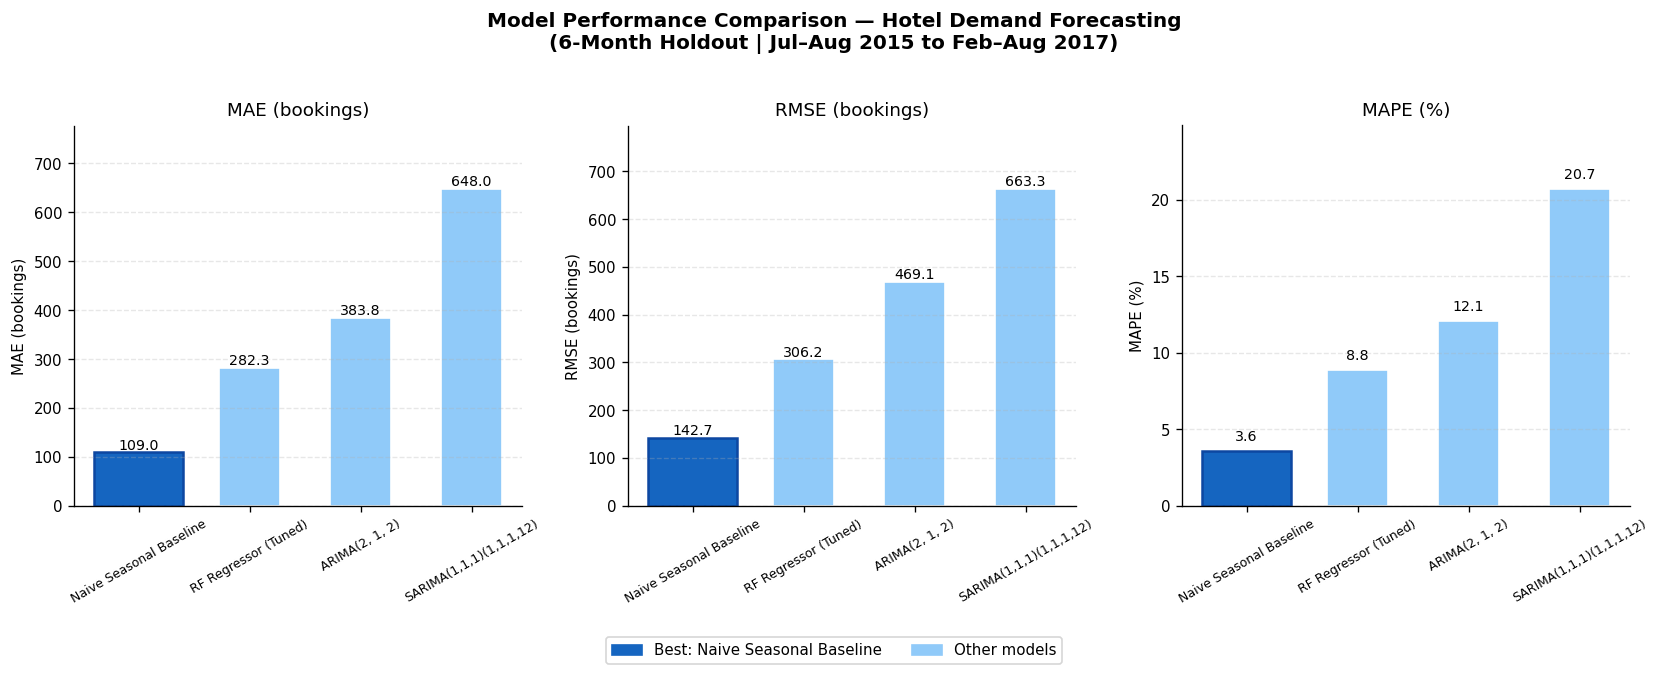

In [66]:
# ── Model Comparison — Visual Bar Chart ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Model Performance Comparison — Hotel Demand Forecasting\n(6-Month Holdout | Jul–Aug 2015 to Feb–Aug 2017)',
             fontsize=12, fontweight='bold', y=1.02)

metrics   = ['MAE', 'RMSE', 'MAPE(%)']
ylabels   = ['MAE (bookings)', 'RMSE (bookings)', 'MAPE (%)']
highlight = full_results['Model'].iloc[0]   # best model

palette = ['#1565C0' if m == highlight else '#90CAF9'
           for m in full_results['Model']]

for ax, metric, ylabel in zip(axes, metrics, ylabels):
    bars = ax.bar(full_results['Model'], full_results[metric],
                  color=palette, edgecolor='white', width=0.55)

    # Value labels on bars
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                f'{h:.1f}', ha='center', va='bottom', fontsize=8.5)

    ax.set_title(ylabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0, full_results[metric].max() * 1.2)
    ax.tick_params(axis='x', rotation=30, labelsize=7.5)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Mark best
    ax.bar(full_results[full_results['Model'] == highlight]['Model'],
           full_results[full_results['Model'] == highlight][metric],
           color='#1565C0', edgecolor='#0D47A1', linewidth=1.5)

# Legend patch
import matplotlib.patches as mpatches
best_patch   = mpatches.Patch(color='#1565C0', label=f'Best: {highlight}')
other_patch  = mpatches.Patch(color='#90CAF9', label='Other models')
fig.legend(handles=[best_patch, other_patch], loc='lower center',
           ncol=2, bbox_to_anchor=(0.5, -0.08), fontsize=9)

plt.tight_layout()
plt.savefig('plot_model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

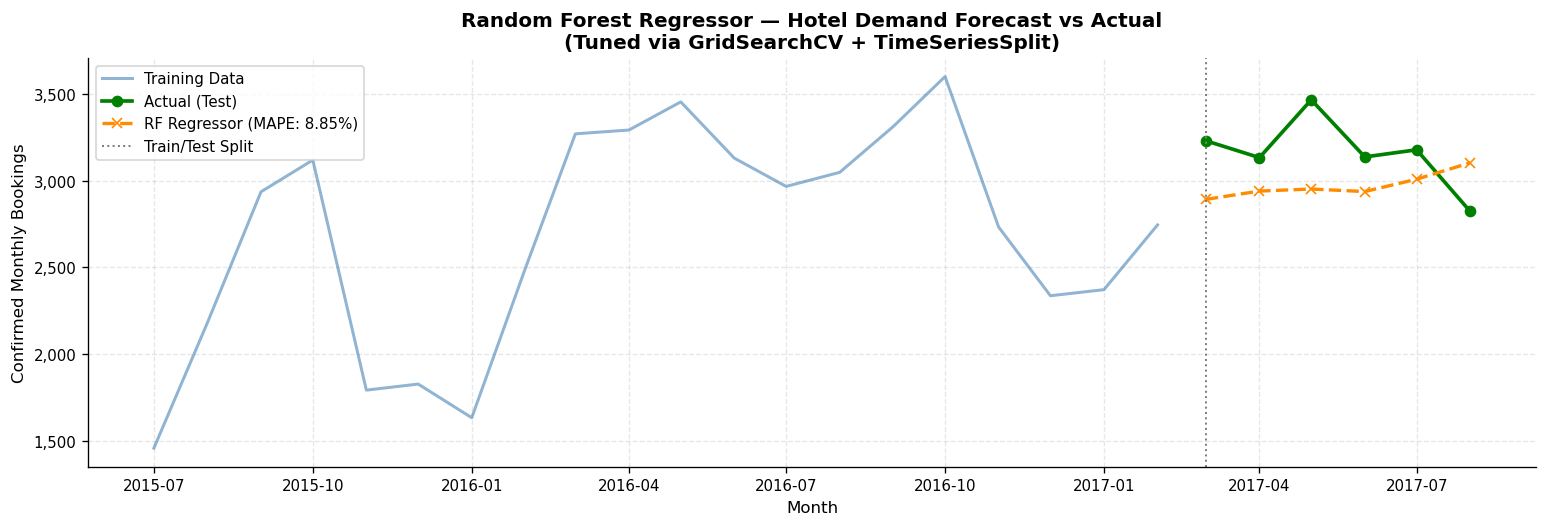

In [67]:
# ── RF Regressor — Forecast vs Actual ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))

ax.plot(train.index, train['bookings'],
        label='Training Data', color='steelblue', alpha=0.6, linewidth=1.8)
ax.plot(test.index, test['bookings'],
        label='Actual (Test)', color='green', marker='o', linewidth=2.2)
ax.plot(y_test.index, rf_pred,
        label=f'RF Regressor (MAPE: {rf_mape:.2f}%)',
        color='darkorange', linestyle='--', marker='x', linewidth=2)

ax.axvline(x=test.index[0], color='gray', linestyle=':', linewidth=1.2, label='Train/Test Split')

ax.set_title('Random Forest Regressor — Hotel Demand Forecast vs Actual\n(Tuned via GridSearchCV + TimeSeriesSplit)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Month', fontsize=10)
ax.set_ylabel('Confirmed Monthly Bookings', fontsize=10)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('plot_rf_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# ── Save Full Results ─────────────────────────────────────────────────────────
full_results.to_csv('model_results_complete.csv', index=False)
feat_imp_df.sort_values('Importance', ascending=False).to_csv('feature_importances.csv', index=False)
print('Saved: model_results_complete.csv')
print('Saved: feature_importances.csv')

Saved: model_results_complete.csv
Saved: feature_importances.csv
